<a href="https://colab.research.google.com/github/ThamilarrasiT/Ridge-and-Lasso-/blob/main/ridge_lasso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
X = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]
n = len(X)
w = 0
b = 0
alpha = 0.1
learning_rate = 0.01
epochs = 1000
for epoch in range(epochs):
    dw = 0
    db = 0
    for i in range(n):
        y_pred = w * X[i] + b
        error = y_pred - y[i]
        dw += error * X[i]
        db += error
    dw = (2/n) * dw + 2 * alpha * w
    db = (2/n) * db + 2 * alpha * b
    w = w - learning_rate * dw
    b = b - learning_rate * db
print("Weight:", w)
print("Bias:", b)
for i in range(n):
    print("Input:", X[i], "Predicted:", w * X[i] + b)

Weight: 1.931057932705652
Bias: 0.18838254946480393
Input: 1 Predicted: 2.119440482170456
Input: 2 Predicted: 4.050498414876108
Input: 3 Predicted: 5.98155634758176
Input: 4 Predicted: 7.912614280287412
Input: 5 Predicted: 9.843672212993063


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split

In [5]:
df= pd.read_csv("/content/ad.csv")
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [7]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

Text(0, 0.5, 'Coefficient Value')

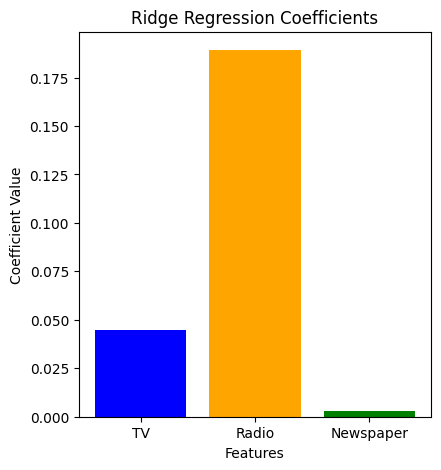

In [10]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(X.columns, ridge.coef_, color=['blue', 'orange', 'green'])
plt.title("Ridge Regression Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")

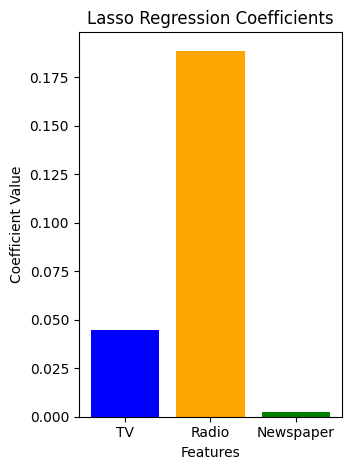

In [12]:
plt.subplot(1, 2, 2)
plt.bar(X.columns, lasso.coef_, color=['blue', 'orange', 'green'])
plt.title("Lasso Regression Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.tight_layout()
plt.show()